> **Note:** This notebook continues from `01_cleaning_SleepKan.ipynb`. We reload the cleaned dataset here before continuing with encoding and EDA.

In [ ]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

# Reload the cleaned dataset produced by 01_cleaning_SleepKan.ipynb
combined_data = pd.read_csv('/content/drive/MyDrive/datasetProjectSleep/combined_data_cleaned.csv')
print('Dataset shape:', combined_data.shape)
combined_data.head()

###Label Encoding
(ถ้าใช้ .map() ของ pandas ไม่ต้อง import LabelEncoder จาก sklearn ต้อง import เฉพาะตอนที่จะใช้ object ของมัน from sklearn.preprocessing import LabelEncoder)

In [34]:

# กำหนดลำดับการ Mapping ด้วยตัวเอง (Manual Ordinal Mapping)
# Yes/No Mapping
binary_mapping = {'Yes': 1, 'No': 0}

# สร้าง DataFrame ใหม่สำหรับเก็บค่าที่ Map แล้ว
combined_data_df2 = pd.DataFrame()

# ทำการ Map ค่าตามลำดับที่กำหนด
combined_data_df2['Use Before Sleep_enc'] = combined_data['Use Before Sleep'].map(binary_mapping)
combined_data_df2['Anxiety/Low Mood_enc'] = combined_data['Anxiety/Low Mood'].map(binary_mapping)
combined_data_df2['Wellness Apps_enc'] = combined_data['Wellness Apps'].map(binary_mapping)

# แสดงผลลัพธ์
display(combined_data_df2)

,Use Before Sleep_enc,Anxiety/Low Mood_enc,Wellness Apps_enc
0,1,0,0
1,0,1,1
2,0,0,1
3,1,1,0
4,1,1,0
...,...,...,...
1176,1,0,1
1177,1,0,0
1178,1,0,1
1179,1,0,0


###OrdinalEncoder
แปลงแบบกำหนดลำดับเองโดยใช้ OrdinalEncoder โดยฟังก์ชันนี้จะคืนค่าเป็น float ดังนั้นถ้าอยากได้เป็นจำนวนเต็ม จะต้องใช้คำสั่ง .astype(int)

In [35]:
from sklearn.preprocessing import OrdinalEncoder

orders = [
    ["No", "Sometimes", "Yes"], #Feel Rested
    ["Bad", "Good"], #Sleep Quality
]

encoder = OrdinalEncoder(categories=orders)

# Encode multiple attributes at once
combined_data_df2[["Feel Rested_enc", "Sleep Quality_enc"]] = encoder.fit_transform(combined_data[["Feel Rested", "Sleep Quality"]]).astype(int)
combined_data_df2

,Use Before Sleep_enc,Anxiety/Low Mood_enc,Wellness Apps_enc,Feel Rested_enc,Sleep Quality_enc
0,1,0,0,2,0
1,0,1,1,0,0
2,0,0,1,1,0
3,1,1,0,2,1
4,1,1,0,2,1
...,...,...,...,...,...
1176,1,0,1,2,1
1177,1,0,0,0,1
1178,1,0,1,2,0
1179,1,0,0,0,0


###Onehot with OneHotEncoder Library

In [36]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False) #🔎 sparse_output=False ปกติ OneHotEncoder จะให้ผลลัพธ์เป็น Sparse Matrix แต่เราบอกให้เป็น array ปกติ (dense array) เพื่อเอาไปทำ DataFrame ได้ง่าย
encoded = encoder.fit_transform(combined_data[['Screen Time Affects Sleep?']])

df_onehot = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['Screen Time Affects Sleep?'])).astype(int) #get_feature_names_out()ช่วยสร้างชื่อคอลัมน์อัตโนมัติ

df_onehot

,Screen Time Affects Sleep?_No,Screen Time Affects Sleep?_Not Sure,Screen Time Affects Sleep?_Yes
0,0,0,1
1,0,0,1
2,0,0,1
3,1,0,0
4,0,0,1
...,...,...,...
1176,0,1,0
1177,0,1,0
1178,0,0,1
1179,0,0,1


### 2.6 รวมคอลัมน์ที่ผ่านการ Encode เข้ากับข้อมูลหลัก
เราจะนำคอลัมน์ตัวเลขจาก `combined_data` มารวมกับ `combined_data_df2` (Encodr&Ordinal) และ `df_onehot` (One-hot)

In [37]:
# เลือกเฉพาะคอลัมน์ที่เป็นตัวเลขจากข้อมูลหลัก
numeric_data = combined_data.select_dtypes(include=['int64']).reset_index(drop=True)

# นำมา concat กันในแนวแกนคอลัมน์ (axis=1)
final_df = pd.concat([numeric_data, combined_data_df2, df_onehot], axis=1)

print('--- ข้อมูลสุดท้ายที่พร้อมสำหรับ Model (Final DataFrame) ---')
print(f'Shape ของข้อมูล: {final_df.shape}')
display(final_df.head())
final_df.info()

--- ข้อมูลสุดท้ายที่พร้อมสำหรับ Model (Final DataFrame) ---
Shape ของข้อมูล: (1181, 12)


,Age,Sleep Hours,Daily Screen Time,Stress Level,Use Before Sleep_enc,Anxiety/Low Mood_enc,Wellness Apps_enc,Feel Rested_enc,Sleep Quality_enc,Screen Time Affects Sleep?_No,Screen Time Affects Sleep?_Not Sure,Screen Time Affects Sleep?_Yes
0,47,4,11,10,1,0,0,2,0,0,0,1
1,48,4,8,7,0,1,1,0,0,0,0,1
2,40,7,10,4,0,0,1,1,0,0,0,1
3,26,10,5,1,1,1,0,2,1,1,0,0
4,47,5,7,7,1,1,0,2,1,0,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1181 entries, 0 to 1180
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   Age                                  1181 non-null   int64
 1   Sleep Hours                          1181 non-null   int64
 2   Daily Screen Time                    1181 non-null   int64
 3   Stress Level                         1181 non-null   int64
 4   Use Before Sleep_enc                 1181 non-null   int64
 5   Anxiety/Low Mood_enc                 1181 non-null   int64
 6   Wellness Apps_enc                    1181 non-null   int64
 7   Feel Rested_enc                      1181 non-null   int64
 8   Sleep Quality_enc                    1181 non-null   int64
 9   Screen Time Affects Sleep?_No        1181 non-null   int64
 10  Screen Time Affects Sleep?_Not Sure  1181 non-null   int64
 11  Screen Time Affects Sleep?_Yes       1181 non-null   int

### 2.8 Update Winsorized Data into Final DataFrame
Update the 'Age' and 'Daily Screen Time' in `final_df` with the winsorized values to reduce the impact of outliers on the model.

In [38]:
from scipy.stats.mstats import winsorize

# Apply winsorization to the actual columns in final_df
final_df['Age'] = winsorize(final_df['Age'], (0.1, 0.1))
final_df['Daily Screen Time'] = winsorize(final_df['Daily Screen Time'], (0.1, 0.1))

print("Updated final_df with winsorized values.")
display(final_df.head())

Updated final_df with winsorized values.


,Age,Sleep Hours,Daily Screen Time,Stress Level,Use Before Sleep_enc,Anxiety/Low Mood_enc,Wellness Apps_enc,Feel Rested_enc,Sleep Quality_enc,Screen Time Affects Sleep?_No,Screen Time Affects Sleep?_Not Sure,Screen Time Affects Sleep?_Yes
0,47,4,10,10,1,0,0,2,0,0,0,1
1,48,4,8,7,0,1,1,0,0,0,0,1
2,40,7,10,4,0,0,1,1,0,0,0,1
3,26,10,5,1,1,1,0,2,1,1,0,0
4,47,5,7,7,1,1,0,2,1,0,0,1


## 3. Exploratory Data Analysis (EDA)
วิเคราะห์ความสัมพันธ์ของตัวแปรและลักษณะการกระจายตัวของข้อมูล

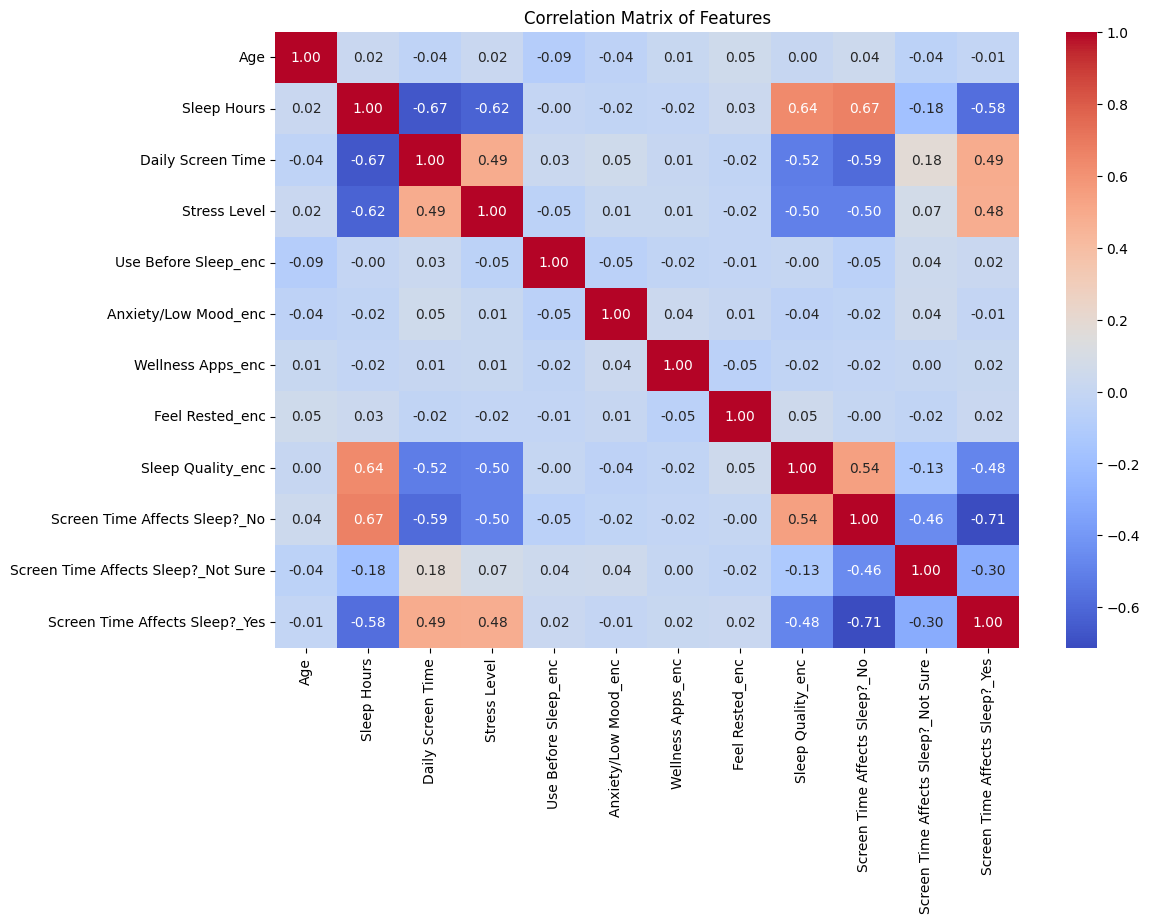

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# 3.1 Heatmap แสดงความสัมพันธ์ (Correlation)
plt.figure(figsize=(12, 8))
correlation_matrix = final_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

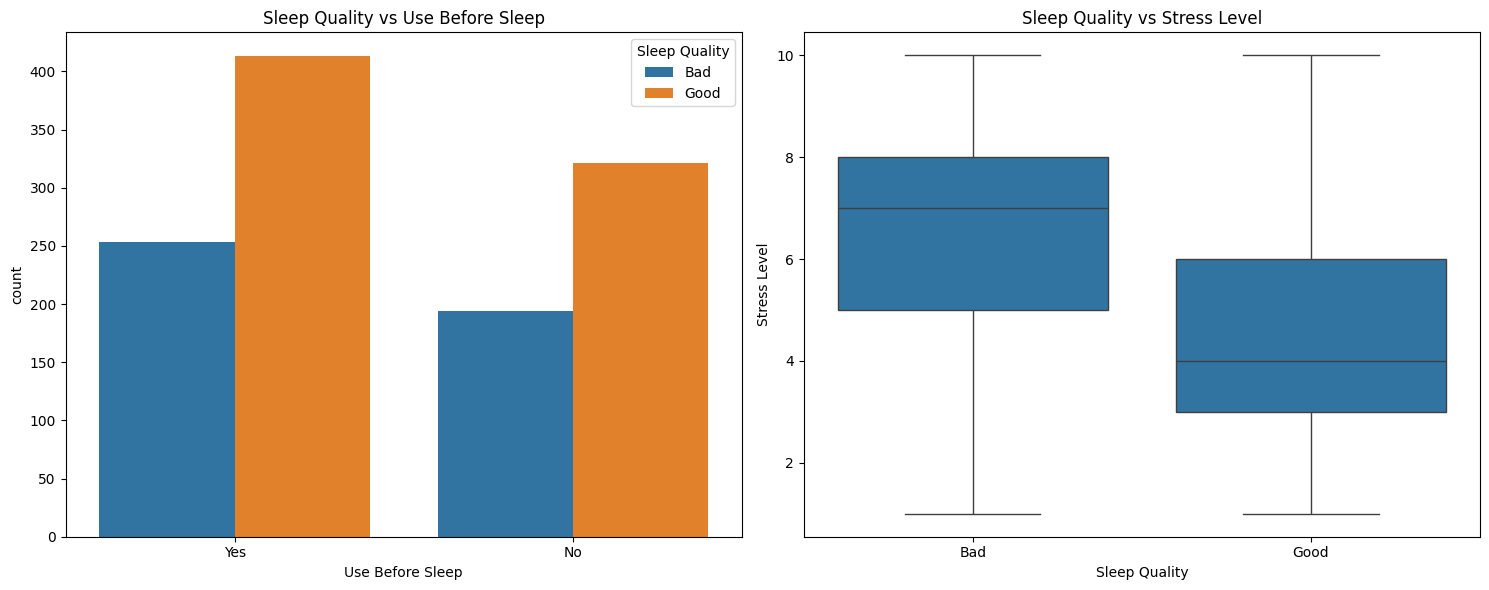

In [40]:
# 3.2 เปรียบเทียบ Sleep Quality กับปัจจัยต่างๆ
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# การใช้มือถือก่อนนอนกับคุณภาพการนอน
sns.countplot(data=combined_data, x='Use Before Sleep', hue='Sleep Quality', ax=axes[0])
axes[0].set_title('Sleep Quality vs Use Before Sleep')

# ความเครียดกับคุณภาพการนอน
sns.boxplot(data=combined_data, x='Sleep Quality', y='Stress Level', ax=axes[1])
axes[1].set_title('Sleep Quality vs Stress Level')

plt.tight_layout()
plt.show()

### 4. เตรียมข้อมูลโดยใช้ Screen Time Affects Sleep? เป็น Target
ทำการ Encode เป้าหมายให้เป็นตัวเลข เพื่อใช้ในการวิเคราะห์ Correlation และสร้างไฟล์สำหรับ Dashboard


In [41]:
from sklearn.preprocessing import LabelEncoder

# 1. เตรียม Target (y) และ Encode เป็นตัวเลข
le = LabelEncoder()
y_encoded = le.fit_transform(combined_data['Screen Time Affects Sleep?'])

# 2. เตรียม DataFrame หลักที่รวม Features และ Target ที่ Encode แล้ว (ยังไม่ Scaling)
cols_to_drop = ['Screen Time Affects Sleep?_No', 'Screen Time Affects Sleep?_Not Sure', 'Screen Time Affects Sleep?_Yes']
final_data_for_csv = final_df.drop(columns=cols_to_drop).copy()
final_data_for_csv['Screen Time Affects Sleep'] = y_encoded

# แสดง Class Mapping
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f'Target classes mapping: {mapping}')
display(final_data_for_csv.head(10))

Target classes mapping: {'No': np.int64(0), 'Not Sure': np.int64(1), 'Yes': np.int64(2)}


,Age,Sleep Hours,Daily Screen Time,Stress Level,Use Before Sleep_enc,Anxiety/Low Mood_enc,Wellness Apps_enc,Feel Rested_enc,Sleep Quality_enc,Screen Time Affects Sleep
0,47,4,10,10,1,0,0,2,0,2
1,48,4,8,7,0,1,1,0,0,2
2,40,7,10,4,0,0,1,1,0,2
3,26,10,5,1,1,1,0,2,1,0
4,47,5,7,7,1,1,0,2,1,2
5,51,6,8,7,1,0,0,0,1,1
6,20,9,3,1,0,0,0,1,1,0
7,21,5,9,7,0,0,0,2,0,0
8,40,8,5,4,1,1,0,0,1,0
9,18,6,9,6,1,1,0,1,1,1


In [42]:
#บันทึกไฟล์ที่ Encode แล้วแต่ยังไม่ Scaling ลง Google Drive
save_path_encoded = '/content/drive/MyDrive/datasetProjectSleep/encoded_sleep_data_ready.csv'
final_data_for_csv.to_csv(save_path_encoded, index=False)
print(f'บันทึกไฟล์ (Encoded only) เรียบร้อยแล้วที่: {save_path_encoded}')

บันทึกไฟล์ (Encoded only) เรียบร้อยแล้วที่: /content/drive/MyDrive/datasetProjectSleep/encoded_sleep_data_ready.csv


In [43]:
path = '/content/drive/MyDrive/datasetProjectSleep/encoded_sleep_data_ready.csv'
sleepdata = pd.read_csv(path) ## Dataset is now stored in a Pandas Dataframe
print ("Dataset Lenght:: ", len(sleepdata)) #แสดงจำนวนแถว (จำนวนข้อมูลทั้งหมด)
print ("Dataset Shape:: ", sleepdata.shape) #แสดงขนาดข้อมูลในรูปแบบ (จำนวนแถว, จำนวนคอลัมน์)
sleepdata

Dataset Lenght::  1181
Dataset Shape::  (1181, 10)


,Age,Sleep Hours,Daily Screen Time,Stress Level,Use Before Sleep_enc,Anxiety/Low Mood_enc,Wellness Apps_enc,Feel Rested_enc,Sleep Quality_enc,Screen Time Affects Sleep
0,47,4,10,10,1,0,0,2,0,2
1,48,4,8,7,0,1,1,0,0,2
2,40,7,10,4,0,0,1,1,0,2
3,26,10,5,1,1,1,0,2,1,0
4,47,5,7,7,1,1,0,2,1,2
...,...,...,...,...,...,...,...,...,...,...
1176,21,10,8,4,1,0,1,2,1,1
1177,18,7,8,8,1,0,0,0,1,1
1178,18,7,3,6,1,0,1,2,0,2
1179,18,6,4,6,1,0,0,0,0,2
